✅ Accuracy: 33.33%

📊 Classification Report:
              precision    recall  f1-score   support

          no       0.00      0.00      0.00         2
         yes       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



C:\Users\SARTHAK\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SARTHAK\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SARTHAK\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


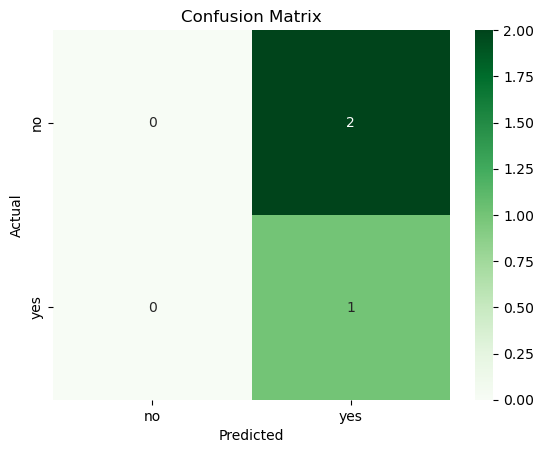

🎯 Prediction for new sample: yes


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\SARTHAK\Desktop\Naive Bayes\Play_tennis.csv")

# Clean and normalize column names
df.columns = df.columns.str.strip().str.lower()

# Encode all categorical columns
label_encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Separate features and target
X = df.drop('play', axis=1)
y = df['play']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Naïve Bayes model
model = CategoricalNB()
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Accuracy: {round(accuracy * 100, 2)}%\n")
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoders['play'].classes_))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoders['play'].classes_,
            yticklabels=label_encoders['play'].classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 🔮 Predict on a new sample
# Example: Outlook=Sunny, Temperature=Cool, Humidity=High, Windy=False
new_sample = pd.DataFrame([['sunny', 'cool', 'high', False]], columns=['outlook', 'temperature', 'humidity', 'windy'])

# Encode the new sample
for col in new_sample.columns:
    new_sample[col] = label_encoders[col].transform(new_sample[col])

# Predict
sample_pred = model.predict(new_sample)
result = label_encoders['play'].inverse_transform(sample_pred)
print("🎯 Prediction for new sample:", result[0])
